这里说频率是指一个机场航班出现的频率

## 加载数据

数据已经预处理过了

In [1]:
import pandas as pd


# 加载数据
pd.set_option('display.max_columns', None)  # 显示所有列
data = pd.read_csv('../../data-hh/my/hh_result/result_2023_2024_05.csv', dtype={'aircraft': str})

# 查看前几行数据，确保加载成功
print(data.head())

print(data.info())

         flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0  KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1  P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2  mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3  jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4  izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   

              a             b    c  year  month  day  weekday  hour  minute  \
0  KNqX4/Q5Noc=  HexFWXqbb8I=  NaN  2023     10    1        6    12      15   
1  AKQNtuL5r6Q=  Mv6HkAiSLUk=  NaN  2023     10    1        6    20      10   
2  n465JzB8Rrw=  N4hmDZN/CJQ=  NaN  2023     10    1        6    16      45   
3  N4hmDZN/CJQ=  n465JzB8Rrw=  NaN  2023     10    1        6    19      40   
4  5t+HPO9Mu/w=  X5e5r3CS4OA=  NaN  2023     10    1        6    13       5   

   second          from            to   unit_price  
0       0  KNqX4/Q5Noc=  HexFWXqbb8I=  

## 编码分类变量

### 新增城市标签

In [2]:
import json
# 加载字典
with open('../../data-hh/my/encoder/city_labels_航班频率加权图标签.json', 'r') as file:
    city_labels_loaded = json.load(file)

print("加载的字典：", city_labels_loaded)

加载的字典： {'+3eoTOkHfoU=': 2, '0Koyk9pJc0s=': 2, '4j3sFPu6XuA=': 2, '9obCP1myMDU=': 0, 'AqmhSoBTk6M=': 2, 'CnmNtb5MOJA=': 0, 'DInJHXgQayE=': 2, 'EIsXRbFUH34=': 2, 'M5N2PVmv8L0=': 2, 'MSFyivV4ETI=': 2, 'N4hmDZN/CJQ=': 0, 'UO2RniR7lJ8=': 2, 'XUXDuFGVfBM=': 2, 'ZCvDTbZuS8Q=': 2, 'gK3uAaRHrOs=': 0, 'jVYRvyHjuvM=': 2, '+O1iBQtlFGU=': 1, '/M8gHzjxpNU=': 0, '0J4jz5aCatU=': 0, 'AKQNtuL5r6Q=': 0, 'AlGb30xUGAU=': 0, 'C3VfOpfT580=': 1, 'Eg2bemFsI9I=': 0, 'FWD6O2fHsIU=': 0, 'KETr2NAmAHE=': 0, 'KFsTKxkC/6g=': 1, 'Qe7TEMbQt6o=': 0, 'QyEgIt0M8Sg=': 0, 'So/c8CkA/Xs=': 0, 'a2cXIUGpIbw=': 0, 'g1hKMyP1V8I=': 0, 'iX2Pe2pxiqQ=': 1, 'lI1bSVMW3Tg=': 1, 'mljW2xeLSiI=': 1, 'tKjndGSl9NQ=': 0, 'vbo2dwBOeps=': 0, 'yypkiQCX5lk=': 0, '+S5aV4Y0s8w=': 1, 'Szk6NJM5C9Y=': 0, 'hwin1ipuzwk=': 0, 'nJFTk7JNmpw=': 0, 'wSF4qXvI044=': 0, 'xIqe+QQIQXQ=': 0, 'zwVGiYamVc0=': 0, '+cjxQ01BFmw=': 1, 'MeDwT1+vyYg=': 0, '/qxKZMQeBus=': 0, '07fT2dsZOJM=': 0, '1/9nd1jNCE0=': 0, '2WRfpdopfDw=': 0, '3nMB4t9SNGw=': 1, '4J2zqjPuTyI=': 0, '4Li

In [3]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

### 新增城市二维嵌入

In [4]:
import json

# 加载字典
with open('../../data-hh/my/encoder/城市嵌入编码_航班频率加权图.json', 'r') as file:
    city_embeddings = json.load(file)

print("加载的字典：", city_embeddings)


加载的字典： {'+3eoTOkHfoU=': [2.1080448627471924, 0.16681121289730072], '0Koyk9pJc0s=': [2.659658670425415, -0.10836305469274521], '4j3sFPu6XuA=': [2.2536356449127197, 0.07387088239192963], '9obCP1myMDU=': [-0.19518019258975983, -0.23304951190948486], 'AqmhSoBTk6M=': [2.390859603881836, 0.22531084716320038], 'CnmNtb5MOJA=': [-0.4544157087802887, 0.07670702040195465], 'DInJHXgQayE=': [2.2896769046783447, 0.46831145882606506], 'EIsXRbFUH34=': [2.350234031677246, 0.22150108218193054], 'M5N2PVmv8L0=': [2.2277913093566895, -0.09280522912740707], 'MSFyivV4ETI=': [2.0588855743408203, 0.11997511982917786], 'N4hmDZN/CJQ=': [0.24426735937595367, 0.01977337896823883], 'UO2RniR7lJ8=': [2.4747231006622314, 0.2974497675895691], 'XUXDuFGVfBM=': [1.3564058542251587, -0.22107930481433868], 'ZCvDTbZuS8Q=': [2.071538209915161, -0.19037237763404846], 'gK3uAaRHrOs=': [0.16043706238269806, -0.3693252503871918], 'jVYRvyHjuvM=': [2.176858425140381, 0.11725752800703049], '+O1iBQtlFGU=': [1.054411768913269, -0.43109

In [5]:
import pandas as pd
import numpy as np

# 将 city_embeddings 转换为 DataFrame
embedding_df = pd.DataFrame.from_dict(city_embeddings, orient='index', columns=['embedding_1', 'embedding_2'])
embedding_df.index.name = 'city'

# 用 'a', 'b', 'c', 'from', 'to' 字段与 embedding_df 合并
data = data.merge(embedding_df, left_on='a', right_index=True, how='left')
data.rename(columns={'embedding_1': 'a_embedding_1', 'embedding_2': 'a_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='b', right_index=True, how='left')
data.rename(columns={'embedding_1': 'b_embedding_1', 'embedding_2': 'b_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='c', right_index=True, how='left')
data.rename(columns={'embedding_1': 'c_embedding_1', 'embedding_2': 'c_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='from', right_index=True, how='left')
data.rename(columns={'embedding_1': 'from_embedding_1', 'embedding_2': 'from_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='to', right_index=True, how='left')
data.rename(columns={'embedding_1': 'to_embedding_1', 'embedding_2': 'to_embedding_2'}, inplace=True)

# 查看添加的新列
print(data[['a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']])


         a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  \
0            -0.301956      -0.680642       0.222681      -0.403314   
1            -0.235445      -0.440215      -0.225903      -0.195987   
2             0.177276      -0.387103       0.244267       0.019773   
3             0.244267       0.019773       0.177276      -0.387103   
4             0.360674      -1.052262      -0.100261      -0.873269   
...                ...            ...            ...            ...   
5932991      -0.392408       0.253940      -0.563885      -0.542664   
5932992      -0.563885      -0.542664      -0.392408       0.253940   
5932993      -0.392408       0.253940      -0.563885      -0.542664   
5932994      -0.563885      -0.542664      -0.081374      -0.040077   
5932995      -0.081374      -0.040077      -0.563885      -0.542664   

         c_embedding_1  c_embedding_2  from_embedding_1  from_embedding_2  \
0                  NaN            NaN         -0.301956         -0.680

### 统计不同城市的频率

In [6]:
# 将 from 和 to 两列合并，并统计每个城市的出现次数
city_count_series = pd.concat([data['from'], data['to']]).value_counts()

# 转换为 city_count 数据框
city_count = city_count_series.reset_index()
city_count.columns = ['city', 'count']

# 3. 创建 city_map，将每个城市映射为其出现次数（或者任何你需要的值）
city_map = dict(zip(city_count['city'], city_count['count']))

# 输出结果
print(city_count)

             city   count
0    vbo2dwBOeps=  464159
1    /M8gHzjxpNU=  438077
2    gK3uAaRHrOs=  428713
3    So/c8CkA/Xs=  413408
4    0J4jz5aCatU=  392097
..            ...     ...
247  wbf1sxPhwNM=     148
248  Qejm7YTJTI4=     146
249  DwCmftDLjPw=     114
250  Eed3EdkMDqg=      50
251  MgrS1LT2KO4=      44

[252 rows x 2 columns]


使用 json 保存和加载 city_map

In [7]:
import json

# 保存 city_map 到 JSON 文件
with open('../../data-hh/my/encoder/city_map_频率编码.json', 'w') as f:
    json.dump(city_map, f)

print("city_map_频率编码 已保存到 city_map_频率编码")

city_map_频率编码 已保存到 city_map_频率编码


### 对'a', 'b', 'c', 'from', 'to'进行频率编码

In [8]:
# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)

# 输出结果
print(city_count)
print(data)

             city   count
0    vbo2dwBOeps=  464159
1    /M8gHzjxpNU=  438077
2    gK3uAaRHrOs=  428713
3    So/c8CkA/Xs=  413408
4    0J4jz5aCatU=  392097
..            ...     ...
247  wbf1sxPhwNM=     148
248  Qejm7YTJTI4=     146
249  DwCmftDLjPw=     114
250  Eed3EdkMDqg=      50
251  MgrS1LT2KO4=      44

[252 rows x 2 columns]
               flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0        KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1        P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2        mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3        jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4        izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   
...               ...     ...    ...      ...   ...     ...       ...  ...   
5932991  BzUm4im0EqA=      窄体  152.0      320     1       1      3.03   99   
5932992  w+GXbx7u3EM=      窄体  152.0    

### 对'flt_no', 'bd_type', 'aircraft'进行标签编码

In [9]:
data.head(5)

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,pax,a,b,c,year,month,day,weekday,hour,minute,second,from,to,unit_price,a_label,b_label,c_label,from_label,to_label,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
0,KgJrsp7Jd78=,窄体,132.0,319,1,1,1.07,25,29186.0,2740.0,NaN,2023,10,1,6,12,15,0,29186,2740,1235.200000,0.0,1.0,NaN,0,1,-0.301956,-0.680642,0.222681,-0.403314,NaN,NaN,-0.301956,-0.680642,0.222681,-0.403314
1,P9IRwar34h0=,窄体,189.0,321,1,1,1.38,151,247830.0,13629.0,NaN,2023,10,1,6,20,10,0,247830,13629,733.311258,0.0,1.0,NaN,0,1,-0.235445,-0.440215,-0.225903,-0.195987,NaN,NaN,-0.235445,-0.440215,-0.225903,-0.195987
2,mJitm0UDfM4=,窄体,132.0,319,1,1,1.57,38,3608.0,189415.0,NaN,2023,10,1,6,16,45,0,3608,189415,844.473684,1.0,0.0,NaN,1,0,0.177276,-0.387103,0.244267,0.019773,NaN,NaN,0.177276,-0.387103,0.244267,0.019773
3,jXr97M1wpn4=,窄体,132.0,319,1,1,1.58,109,189415.0,3608.0,NaN,2023,10,1,6,19,40,0,189415,3608,1280.000000,0.0,1.0,NaN,0,1,0.244267,0.019773,0.177276,-0.387103,NaN,NaN,0.244267,0.019773,0.177276,-0.387103
4,izjfHOxAho4=,窄体,132.0,319,1,1,1.80,124,64716.0,26471.0,NaN,2023,10,1,6,13,5,0,64716,26471,1009.516129,0.0,0.0,NaN,0,0,0.360674,-1.052262,-0.100261,-0.873269,NaN,NaN,0.360674,-1.052262,-0.100261,-0.873269


In [10]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
# categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 创建并应用 LabelEncoder
label_encoders = {}

# 创建保存编码器的文件夹（如果文件夹不存在）
save_folder = '../../data-hh/my/encoder/'
os.makedirs(save_folder, exist_ok=True)  # 如果文件夹已存在，不会报错

# 遍历每个分类特征，使用 LabelEncoder 对其进行编码
for col in categorical_columns:
    le = LabelEncoder()  # 创建一个 LabelEncoder 实例
    data[col] = le.fit_transform(data[col])  # 对训练数据中的分类特征进行编码
    label_encoders[col] = le  # 将每个特征的编码器保存到字典中，方便后续使用

    # 保存每个编码器到指定文件夹
    encoder_path = os.path.join(save_folder, f"{col}_encoder_all.pkl")  # 构建保存路径
    joblib.dump(le, encoder_path)  # 使用 joblib 将编码器保存为 pkl 文件
    print(f"{col} 的编码器已保存为 {encoder_path}")  # 输出保存的路径

flt_no 的编码器已保存为 ../../data-hh/my/encoder/flt_no_encoder_all.pkl
bd_type 的编码器已保存为 ../../data-hh/my/encoder/bd_type_encoder_all.pkl
aircraft 的编码器已保存为 ../../data-hh/my/encoder/aircraft_encoder_all.pkl


## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [11]:
# 特征列
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft',  'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','holiday', 'hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label']]

# 有abc，有标签，有嵌入
X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 删除了abc，但有标签，有嵌入
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 目标列
y = data['pax']

In [12]:
test_x = X.head(1)
test_x

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,a,b,c,year,month,day,weekday,hour,minute,second,from,to,unit_price,a_label,b_label,c_label,from_label,to_label,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
0,4013,3,132.0,1,1,1,1.07,29186.0,2740.0,NaN,2023,10,1,6,12,15,0,29186,2740,1235.2,0.0,1.0,NaN,0,1,-0.301956,-0.680642,0.222681,-0.403314,NaN,NaN,-0.301956,-0.680642,0.222681,-0.403314


In [13]:
y.head(5)

0     25
1    151
2     38
3    109
4    124
Name: pax, dtype: int64

### 对x进行标准化

In [14]:
from sklearn.preprocessing import StandardScaler

# 对所有特征进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将标准化后的数据转回 DataFrame 格式
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 查看结果
pd.set_option('display.max_columns', None)  # 显示所有列
print(X_scaled.head(1))


# 保存 scaler
joblib.dump(scaler, '../../data-hh/my/encoder/standard_scaler_x.pkl')
print("x的标准化器已保存为 standard_scaler_x.pkl")

    flt_no   bd_type       cap  aircraft      legs    leg_no  duration  \
0 -0.49282  0.301791 -1.075156 -1.185921 -0.805599 -0.554419 -1.263568   

          a         b   c      year    month       day   weekday      hour  \
0 -1.462479 -1.405527 NaN -0.647984  1.33871 -1.685597  1.494085 -0.349109   

     minute  second      from        to  unit_price   a_label   b_label  \
0 -0.630518     0.0 -1.375926 -1.558559    1.148965 -0.364187  1.641451   

   c_label  from_label  to_label  a_embedding_1  a_embedding_2  b_embedding_1  \
0      NaN   -0.388547  1.686182      -0.098289      -1.164096       0.918291   

   b_embedding_2  c_embedding_1  c_embedding_2  from_embedding_1  \
0      -0.555694            NaN            NaN         -0.112679   

   from_embedding_2  to_embedding_1  to_embedding_2  
0         -1.173198        0.878343        -0.54766  
x的标准化器已保存为 standard_scaler_x.pkl


In [15]:
# 获取第一行的关键信息
first_row = X_scaled.head(1)
flt_no = first_row['flt_no'].values[0]  # 假设flt_no是索引
year = first_row['year'].values[0]
month = first_row['month'].values[0]
day = first_row['day'].values[0]

# 筛选出相同航班和日期的所有行
filtered_rows = X_scaled[
    (X_scaled['flt_no'] == flt_no) &  # 相同航班号
    (X_scaled['year'] == year) &   # 相同年份
    (X_scaled['month'] == month) & # 相同月份
    (X_scaled['day'] == day)       # 相同日期
]

print("筛选结果：")
print(filtered_rows)

筛选结果：
    flt_no   bd_type       cap  aircraft      legs    leg_no  duration  \
0 -0.49282  0.301791 -1.075156 -1.185921 -0.805599 -0.554419 -1.263568   

          a         b   c      year    month       day   weekday      hour  \
0 -1.462479 -1.405527 NaN -0.647984  1.33871 -1.685597  1.494085 -0.349109   

     minute  second      from        to  unit_price   a_label   b_label  \
0 -0.630518     0.0 -1.375926 -1.558559    1.148965 -0.364187  1.641451   

   c_label  from_label  to_label  a_embedding_1  a_embedding_2  b_embedding_1  \
0      NaN   -0.388547  1.686182      -0.098289      -1.164096       0.918291   

   b_embedding_2  c_embedding_1  c_embedding_2  from_embedding_1  \
0      -0.555694            NaN            NaN         -0.112679   

   from_embedding_2  to_embedding_1  to_embedding_2  
0         -1.173198        0.878343        -0.54766  


### 对y进行标准化

In [16]:
# 对目标列 y 进行标准化
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # 将 y 转换为 2D 数组进行标准化

# 转换回 DataFrame 格式
y_scaled = pd.DataFrame(y_scaled, columns=['pax_scaled'])

# 查看标准化后的 y
print(y_scaled.head())

# 保存 y 的 scaler
joblib.dump(scaler_y, '../../data-hh/my/encoder/standard_scaler_y.pkl')
print("y的标准化器已保存为 standard_scaler_y.pkl")

   pax_scaled
0   -1.692504
1    0.866728
2   -1.428456
3    0.013651
4    0.318321
y的标准化器已保存为 standard_scaler_y.pkl


## 训练XGBoost模型

In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 自定义 SMAPE 函数
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return np.mean(diff / denominator) * 100

# 自定义评估函数
def smape_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    smape_value = smape(y_true, y_pred)
    return 'SMAPE', smape_value

# 数据划分
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 输出数据集大小
print(f'训练集大小: {X_train.shape[0]}')
print(f'验证集大小: {X_val.shape[0]}')
print(f'测试集大小: {X_test.shape[0]}')

# 转换为 DMatrix 格式
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# 设置参数
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.2,
    'max_depth': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'alpha': 1,
    "lambda":1
}

# 设置评估集
evals = [(dtrain, 'train'), (dval, 'validation')]

# 训练模型，使用自定义评估指标
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=10,
    custom_metric=smape_eval,  # 使用 custom_metric 参数
    verbose_eval=10 #隔多少轮显示一次
)

# 预测测试集
y_pred = model.predict(dtest)

# # 测试集 SMAPE 评估
# test_smape = smape(y_test, y_pred)
# print(f'SMAPE on Test Set: {test_smape:.2f}%')

# # 测试集 MSE 评估
# mse = mean_squared_error(y_test, y_pred)
# print(f'Mean Squared Error on Test Set: {mse}')


训练集大小: 4746396
验证集大小: 593300
测试集大小: 593300
[0]	train-rmse:0.87116	train-SMAPE:151.13761	validation-rmse:0.87092	validation-SMAPE:151.07741
[10]	train-rmse:0.53839	train-SMAPE:85.04677	validation-rmse:0.53974	validation-SMAPE:85.20917
[20]	train-rmse:0.50227	train-SMAPE:79.75947	validation-rmse:0.50494	validation-SMAPE:80.05517
[30]	train-rmse:0.48543	train-SMAPE:77.60404	validation-rmse:0.48924	validation-SMAPE:78.03224
[40]	train-rmse:0.47390	train-SMAPE:76.16633	validation-rmse:0.47875	validation-SMAPE:76.68368
[50]	train-rmse:0.46677	train-SMAPE:75.24472	validation-rmse:0.47250	validation-SMAPE:75.86374
[60]	train-rmse:0.46032	train-SMAPE:74.37832	validation-rmse:0.46668	validation-SMAPE:75.05910
[70]	train-rmse:0.45438	train-SMAPE:73.57149	validation-rmse:0.46139	validation-SMAPE:74.31646
[80]	train-rmse:0.44882	train-SMAPE:72.80781	validation-rmse:0.45639	validation-SMAPE:73.61382
[90]	train-rmse:0.44485	train-SMAPE:72.27170	validation-rmse:0.45294	validation-SMAPE:73.12792
[100]	

[850]	train-rmse:0.34828	train-SMAPE:60.00385	validation-rmse:0.39168	validation-SMAPE:64.54230
[860]	train-rmse:0.34767	train-SMAPE:59.93118	validation-rmse:0.39144	validation-SMAPE:64.51063
[870]	train-rmse:0.34708	train-SMAPE:59.85789	validation-rmse:0.39124	validation-SMAPE:64.48295
[880]	train-rmse:0.34645	train-SMAPE:59.77835	validation-rmse:0.39106	validation-SMAPE:64.45657
[890]	train-rmse:0.34588	train-SMAPE:59.70379	validation-rmse:0.39085	validation-SMAPE:64.42498
[900]	train-rmse:0.34527	train-SMAPE:59.62748	validation-rmse:0.39067	validation-SMAPE:64.39408
[910]	train-rmse:0.34465	train-SMAPE:59.54899	validation-rmse:0.39043	validation-SMAPE:64.35641
[920]	train-rmse:0.34402	train-SMAPE:59.46678	validation-rmse:0.39019	validation-SMAPE:64.31746
[930]	train-rmse:0.34346	train-SMAPE:59.40020	validation-rmse:0.39005	validation-SMAPE:64.29676
[940]	train-rmse:0.34289	train-SMAPE:59.32735	validation-rmse:0.38982	validation-SMAPE:64.26081
[950]	train-rmse:0.34223	train-SMAPE:59.

In [18]:
y_pred

array([ 1.0466982 ,  0.44689834,  0.7381158 , ..., -0.7800372 ,
        0.35089698,  0.69159734], dtype=float32)

In [19]:
# 反标准化 y_test
y_test_original = scaler_y.inverse_transform(y_test.values.reshape(-1, 1))

# 反标准化预测结果 y_pred
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

In [20]:
y_test_original



array([[157.],
       [132.],
       [153.],
       ...,
       [ 69.],
       [177.],
       [164.]])

In [21]:
y_pred_original

array([[159.86058],
       [130.3303 ],
       [144.66797],
       ...,
       [ 69.92394],
       [125.60383],
       [142.3777 ]], dtype=float32)

In [22]:
# 正确的写法
test_results = list(zip(y_test_original[:100], y_pred_original[:100]))  # 真实值和预测值

print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results[:40]):
    # 如果是多维数组，使用 .item() 转换为标量
    true_value = true_value.item() if isinstance(true_value, np.ndarray) else true_value
    pred_value = pred_value.item() if isinstance(pred_value, np.ndarray) else pred_value
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")



20条测试结果（真实值 vs 预测值）:
第1条: 真实值=157.0, 预测值=159.86
第2条: 真实值=132.0, 预测值=130.33
第3条: 真实值=153.0, 预测值=144.67
第4条: 真实值=111.0, 预测值=95.44
第5条: 真实值=53.99999999999999, 预测值=70.09
第6条: 真实值=192.0, 预测值=195.60
第7条: 真实值=117.0, 预测值=122.91
第8条: 真实值=60.0, 预测值=65.49
第9条: 真实值=144.0, 预测值=140.59
第10条: 真实值=175.0, 预测值=170.26
第11条: 真实值=85.0, 预测值=130.10
第12条: 真实值=90.0, 预测值=86.05
第13条: 真实值=134.0, 预测值=161.41
第14条: 真实值=93.0, 预测值=110.88
第15条: 真实值=117.0, 预测值=143.09
第16条: 真实值=38.0, 预测值=51.53
第17条: 真实值=168.0, 预测值=159.28
第18条: 真实值=106.0, 预测值=117.08
第19条: 真实值=18.0, 预测值=49.30
第20条: 真实值=131.0, 预测值=115.96
第21条: 真实值=101.0, 预测值=84.42
第22条: 真实值=129.0, 预测值=82.78
第23条: 真实值=144.0, 预测值=133.05
第24条: 真实值=63.0, 预测值=85.08
第25条: 真实值=103.0, 预测值=69.27
第26条: 真实值=172.0, 预测值=169.08
第27条: 真实值=169.0, 预测值=180.55
第28条: 真实值=142.0, 预测值=105.93
第29条: 真实值=30.0, 预测值=56.22
第30条: 真实值=96.0, 预测值=96.96
第31条: 真实值=156.0, 预测值=148.13
第32条: 真实值=118.0, 预测值=134.89
第33条: 真实值=2.0, 预测值=2.08
第34条: 真实值=149.0, 预测值=141.03
第35条: 真实值=166.0, 预测值=143.03
第36条: 真实值=53.9999999

In [23]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_pred - y_true)
    
    # 避免除以零，将分母中为零的项替换为一个小值
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = 100 * np.mean(diff / denominator)
    return smape


def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    
    # 避免除以零，将 y_true 中的零值替换为一个小值
    y_true = np.where(y_true == 0, 1e-8, y_true)
    
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape


# 假设 y_test 和 y_pred 已经是标准化反归一化后的数据
# 将其转换为一维数组以确保形状一致
y_test = np.array(y_test_original).ravel()
y_pred = np.array(y_pred_original).ravel()

# 评估指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')
print(f'R-squared (R²): {r2:.4f}')


Mean Squared Error (MSE): 366.2189
Root Mean Squared Error (RMSE): 19.1368
Mean Absolute Error (MAE): 14.4426
Mean Absolute Percentage Error (MAPE): 25.1344%
Symmetric Mean Absolute Percentage Error (SMAPE): 18.1799%
R-squared (R²): 0.8490


似乎对于较小值预测存在误差

In [24]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 366.2189
Root Mean Squared Error (RMSE): 19.1368
Mean Absolute Error (MAE): 14.4426
Mean Absolute Percentage Error (MAPE): 25.1344%
Symmetric Mean Absolute Percentage Error (SMAPE): 18.1799%


## 保存模型

In [26]:
model.save_model("../../data-hh/my/模型文件/频率编码/归一化_xgboost_model_1000.json")
print("模型已保存为 xgboost_model_1000.json")

模型已保存为 xgboost_model_1000.json


In [27]:
# 将筛选结果转换为DMatrix并预测
dtest = xgb.DMatrix(filtered_rows)
scaled_predictions = model.predict(dtest)
scaled_predictions_2d = scaled_predictions.reshape(-1, 1)
predictions = scaler_y.inverse_transform(scaled_predictions_2d)

print("\n预测结果：")
for i, pred in enumerate(predictions):
    print(f"航段 {i+1}: {pred[0]:.2f}")


预测结果：
航段 1: 15.42


## 超参数设置

## 不同特征重要程度测试

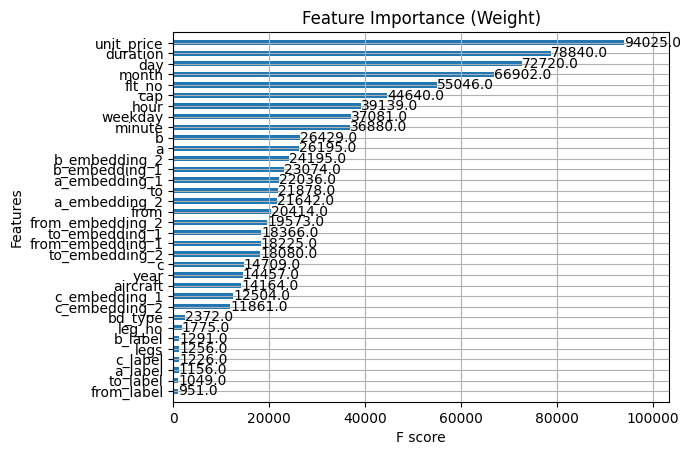

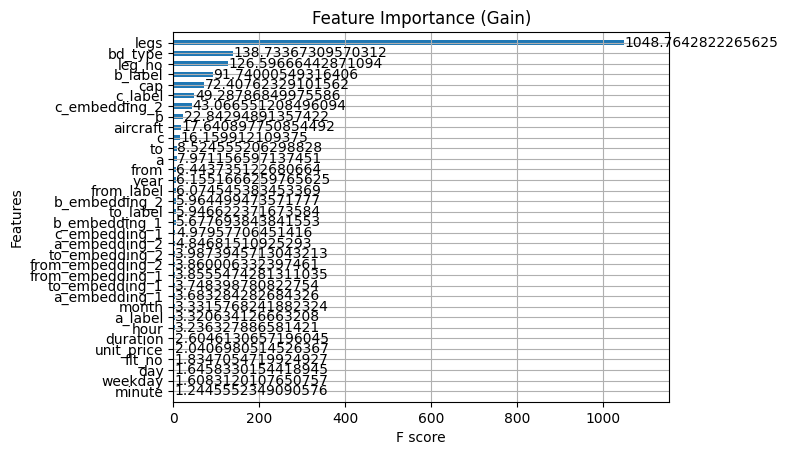

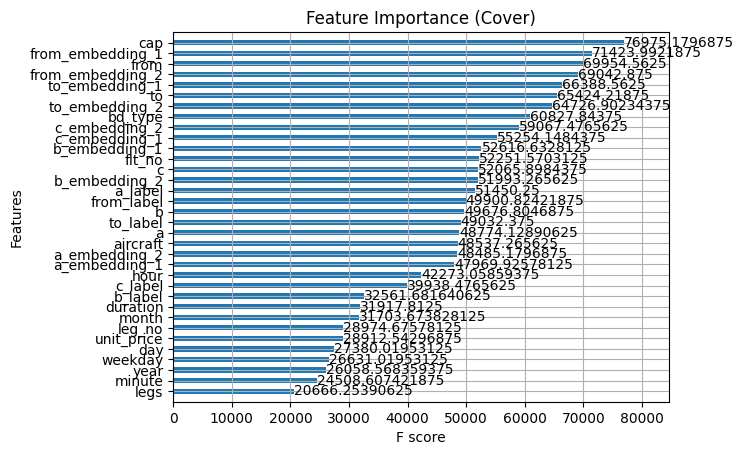

In [28]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 假设 model 是训练好的 XGBoost 模型
xgb.plot_importance(model, importance_type='weight', title="Feature Importance (Weight)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='gain', title="Feature Importance (Gain)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='cover', title="Feature Importance (Cover)", height=0.5)
plt.show()